In [1]:
## Predicting Road Accident Risk Kaggle Competition Dataset

# GOAL: Predict the likelihood of accidents on different types of roads.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tabulate
from IPython.display import display, HTML
from sklearn import set_config
set_config(display='text')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix

# Data Collection

In [2]:
train = pd.read_csv('/Users/tanvirsingh/Downloads/playground-series-s5e10/train.csv')
test = pd.read_csv('/Users/tanvirsingh/Downloads/playground-series-s5e10/test.csv')

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [4]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172585 entries, 0 to 172584
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      172585 non-null  int64  
 1   road_type               172585 non-null  object 
 2   num_lanes               172585 non-null  int64  
 3   curvature               172585 non-null  float64
 4   speed_limit             172585 non-null  int64  
 5   lighting                172585 non-null  object 
 6   weather                 172585 non-null  object 
 7   road_signs_present      172585 non-null  bool   
 8   public_road             172585 non-null  bool   
 9   time_of_day             172585 non-null  object 
 10  holiday                 172585 non-null  bool   
 11  school_season           172585 non-null  bool   
 12  num_reported_accidents  172585 non-null  int64  
dtypes: bool(4), float64(1), int64(4), object(4)
memory usage: 12.5+ MB


In [5]:
# Number of rows and features
print('Train shape:', train.shape)
print('Test shape:', test.shape)

Train shape: (517754, 14)
Test shape: (172585, 13)


In [6]:
train.isnull().sum() # No missing values

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [7]:
test.isnull().sum() # No missing values

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
dtype: int64

In [8]:
train.head() # 12 Features, 1 Target (accident_risk)

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [9]:
# Display feature types in table format
feature_table = pd.DataFrame({
    'Feature': [
        'curvature', 'speed_limit', 'num_lanes', 'num_reported_accidents',
        'lighting', 'weather', 'road_type', 'road_signs_present',
        'public_road', 'time_of_day', 'holiday', 'school_season', 'accident_risk'
    ],
    'Type': [
        'Continuous', 'Discrete Ordinal', 'Discrete Ordinal', 'Discrete Count',
        'Categorical', 'Categorical', 'Categorical', 'Categorical',
        'Categorical', 'Categorical', 'Categorical', 'Categorical', 'Continuous (Target)'
    ],
    'Values': [
        '0.0 – 1.0', '25, 35, 45, 60, 70', '1, 2, 3, 4', '0 – 7',
        'daylight, dim, night', 'clear, foggy, rainy', 'highway, rural, urban', 'True, False',
        'True, False', 'morning, afternoon, evening', 'True, False', 'True, False', '0.0 – 1.0'
    ],
    'Missing': [0] * 13,
    'Outliers': [
        'None', 'None', 'None', 'None',
        'N/A', 'N/A', 'N/A', 'N/A',
        'N/A', 'N/A', 'N/A', 'N/A', 'None'
    ]
})

display(HTML(tabulate.tabulate(
    feature_table.values,
    tablefmt='html',
    headers=feature_table.columns.tolist()
)))

Feature,Type,Values,Missing,Outliers
curvature,Continuous,0.0 – 1.0,0,None
speed_limit,Discrete Ordinal,"25, 35, 45, 60, 70",0,None
num_lanes,Discrete Ordinal,"1, 2, 3, 4",0,None
num_reported_accidents,Discrete Count,0 – 7,0,None
lighting,Categorical,"daylight, dim, night",0,N/A
weather,Categorical,"clear, foggy, rainy",0,N/A
road_type,Categorical,"highway, rural, urban",0,N/A
road_signs_present,Categorical,"True, False",0,N/A
public_road,Categorical,"True, False",0,N/A
time_of_day,Categorical,"morning, afternoon, evening",0,N/A


### Outliers
There are no extreme values in the dataset that would hinder the model perfomance. An outlier is a value that falls below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR where Q1 and Q3 are the 25th and 75th percentiles of the 
data respectively, and IQR (Interquartile Range) is the difference between Q3 and Q1.

In [10]:
train['accident_risk'].describe() # regression task (continuous target)

count    517754.000000
mean          0.352377
std           0.166417
min           0.000000
25%           0.230000
50%           0.340000
75%           0.460000
max           1.000000
Name: accident_risk, dtype: float64

<Axes: xlabel='accident_risk', ylabel='Count'>

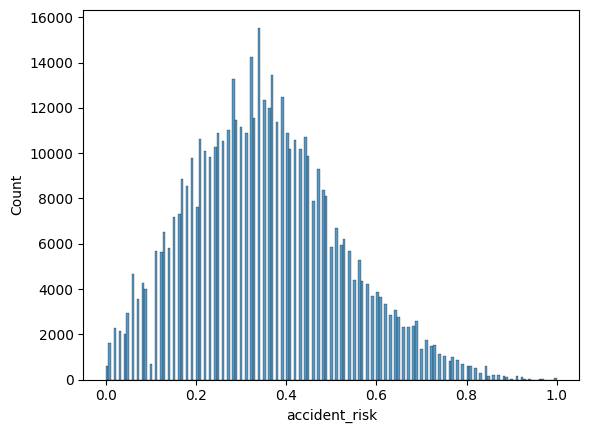

In [11]:
# accident_risk general distribution
sns.histplot(train['accident_risk'])

# Data Preprocessing

## Turn Regression Problem Into Classification Problem
- Idea is to split the accident_risk into two categories:
  - Low risk
  - High risk

In [12]:
# risk_level converting accident_risk values >= 0.5  as true (1) and the rest false (0)
train['risk_level'] = (train['accident_risk'] >= 0.5).astype(int)
# For plotting, 0 = Low Risk, 1 = High Risk
train['risk_label'] = train['risk_level'].map({0: 'Low Risk', 1: 'High Risk'})

In [13]:
train['risk_label'].value_counts() # Raw counts to check for class imbalance

risk_label
Low Risk     420711
High Risk     97043
Name: count, dtype: int64

In [14]:
print(train['risk_label'].value_counts(normalize=True)) # Proportions

risk_label
Low Risk     0.812569
High Risk    0.187431
Name: proportion, dtype: float64


In [15]:
## Assign colors for plotting (Low Risk - Blue, High Risk - Red)
palette = {
    'Low Risk': '#94D4F2',   
    'High Risk': '#FC5151'   
}

# Exploratory Data Analysis

## Numerical Features
- speed_limit (discrete ordinal)
- curvature (continuous)
- num_lanes (discrete ordinal)
- num_reported_accidents (discrete count)

### Check Discrete Values

In [16]:
train['num_lanes'].unique()

array([2, 4, 1, 3])

In [17]:
train['num_reported_accidents'].unique()

array([1, 0, 2, 3, 4, 5, 6, 7])

In [18]:
train['speed_limit'].unique()

array([35, 70, 60, 45, 25])

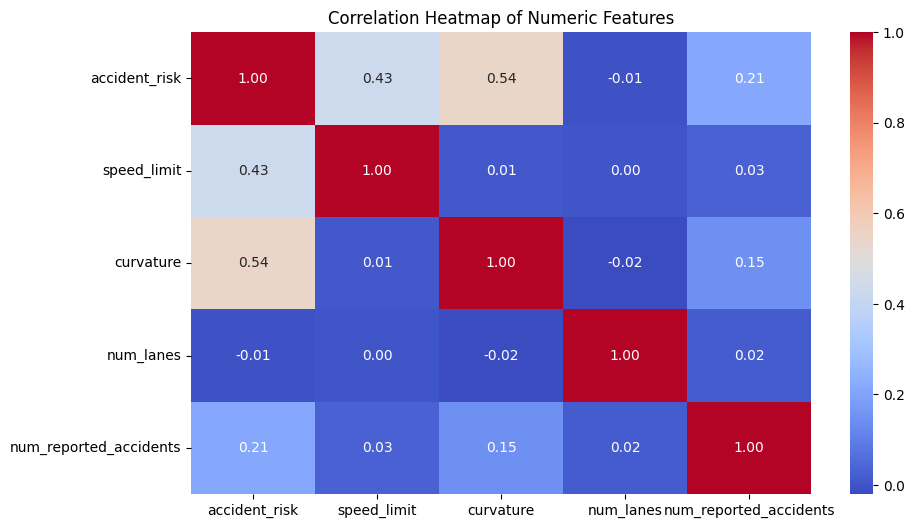

In [19]:
## Check correlation of numeric features
corr = train[['accident_risk', 'speed_limit', 'curvature', 'num_lanes', 'num_reported_accidents']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

### Correlation Heatmap Conclusions
- accident_risk has the highest correlation with speed_limit and curvature, where roads with higher speed limit and curvature tend to have higher accident risk. 
- num_lanes has very little to no correlation with accident_risk, which suggests that num_lanes is unlikely to be a strong predictor. This feature also has no correlation with speed_limit and curvature.
- num_reported_accidents has weak positive relationships with accident_risk and curvature, suggesting that a greater number of reports of accidents is associated with higher accident_risk curvature.

** Caveat: Discrete features may not be suitable to plot in a correlation heatmap, so further plotting will be done seperately.

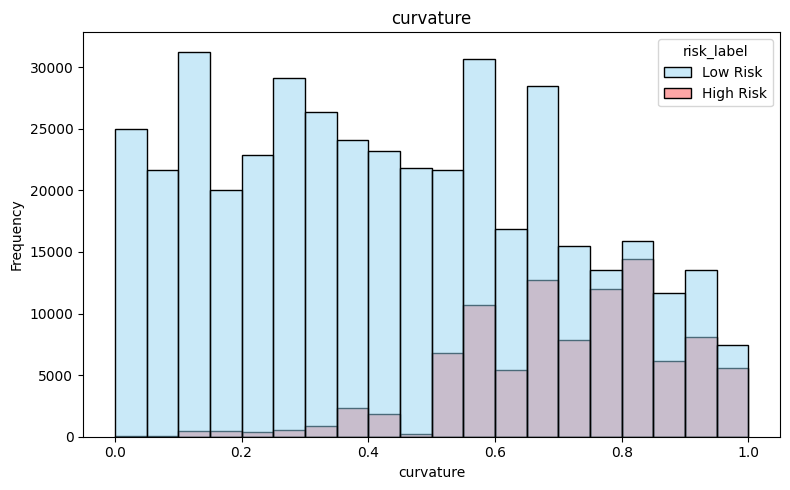

In [20]:
# Histogram of curvature distribution by risk label (continuous feature)
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=train,
    x='curvature',
    hue='risk_label',
    bins=20,
    multiple='layer',   
    palette=palette,
    alpha=0.5,
    ax=ax
)
ax.set_title('curvature')
ax.set_xlabel('curvature')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

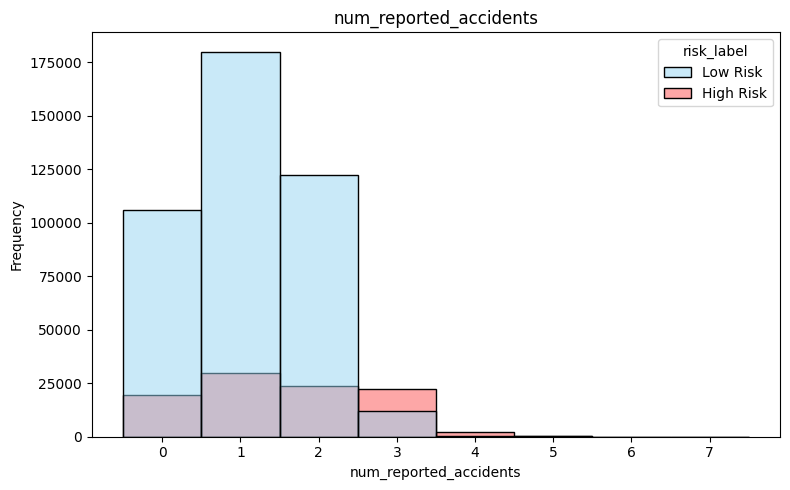

In [21]:
# Histogram of num_reported_accidents distribution by risk label (discrete count feature)
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=train,
    x='num_reported_accidents',
    hue='risk_label',
    bins=train['num_reported_accidents'].nunique(),
    discrete=True,           
    multiple='layer',
    palette=palette,
    alpha=0.5,
    ax=ax
)
ax.set_title('num_reported_accidents')
ax.set_xlabel('num_reported_accidents')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

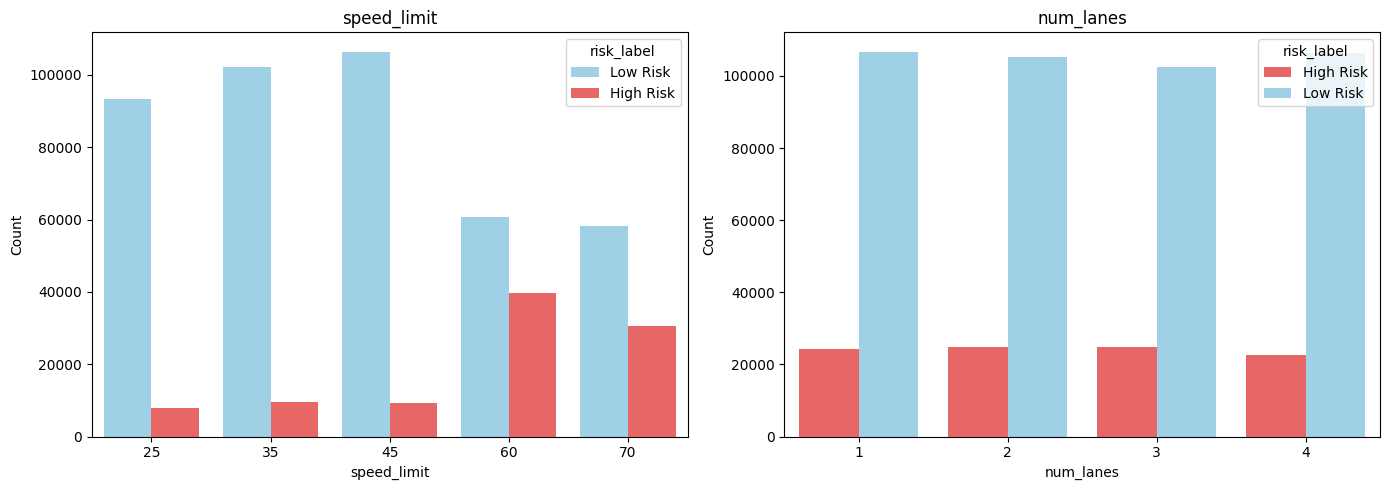

In [22]:
# Histogram of speed_limit and num_lanes distributions by risk label (discrete ordinal features)
ordinal_features = ['speed_limit', 'num_lanes']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(ordinal_features):
    sns.countplot(
        data=train,
        x=col,
        hue='risk_label',
        palette=palette,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

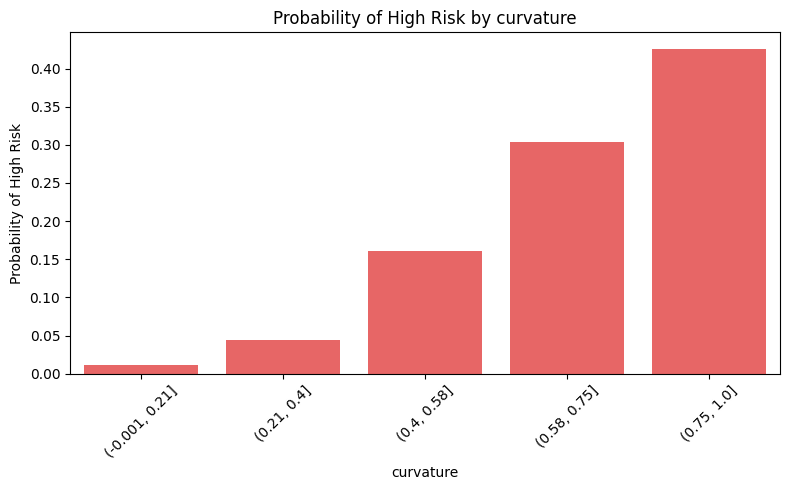

In [23]:
## Probability of High Risk of Curvature
fig, ax = plt.subplots(figsize=(8, 5))
train['curvature_bin'] = pd.qcut(train['curvature'], q=5, duplicates='drop')
prob_df = (
    train.groupby('curvature_bin', observed=True)['risk_level']
    .mean()
    .reset_index(name='prob_high_risk')
)
sns.barplot(data=prob_df, x='curvature_bin', y='prob_high_risk', color='#FC5151', ax=ax)
ax.set_title('Probability of High Risk by curvature')
ax.set_xlabel('curvature')
ax.set_ylabel('Probability of High Risk')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

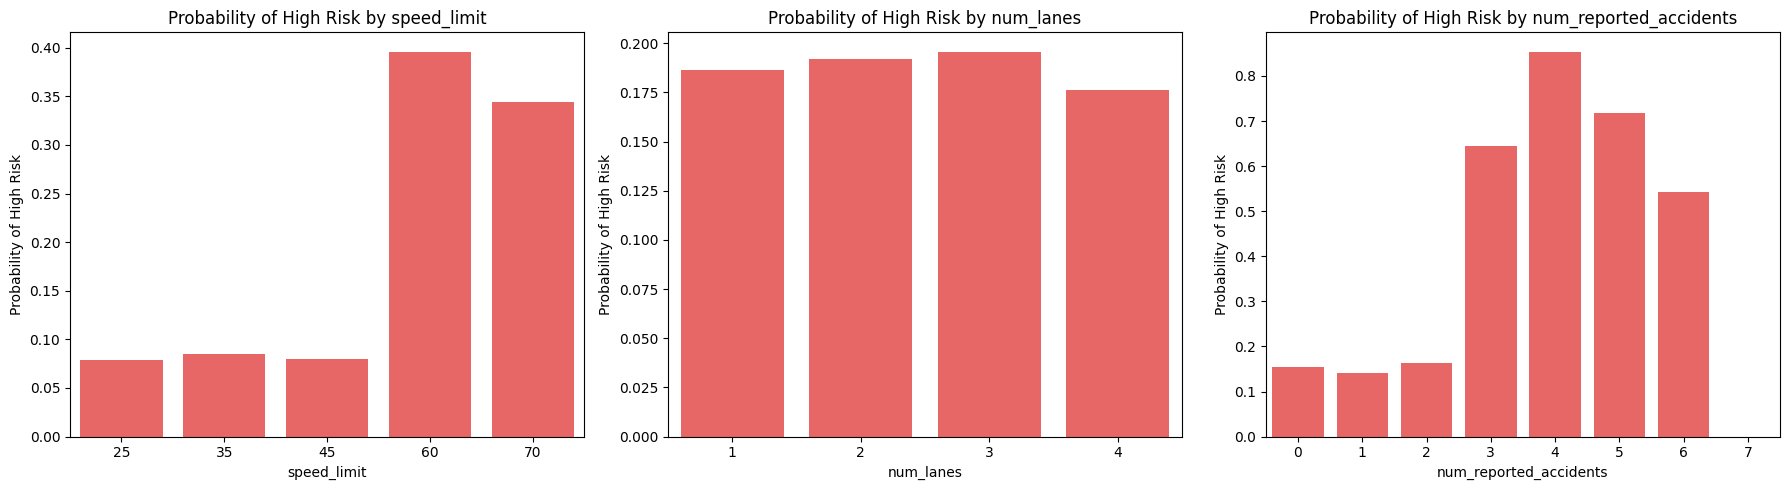

In [24]:
## Probability of High Risk of Discrete Features
raw_features = ['speed_limit', 'num_lanes', 'num_reported_accidents']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(raw_features):
    prob_df = (
        train.groupby(col, observed=True)['risk_level']
        .mean()
        .reset_index(name='prob_high_risk')
    )
    sns.barplot(
        data=prob_df,
        x=col,
        y='prob_high_risk',
        color='#FC5151',
        ax=axes[i]
    )
    axes[i].set_title(f'Probability of High Risk by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Probability of High Risk')
plt.tight_layout()
plt.show()

In [25]:
## Probability of High Risk in Tables
num_tables = {}
overall_prob = train['risk_level'].mean()

continuous = ['curvature']
discrete = ['speed_limit', 'num_lanes', 'num_reported_accidents']

for num in continuous:
    bins = pd.qcut(train[num], q=5, duplicates='drop')
    num_prob = train.groupby(bins, observed=True)['risk_level'].agg(
        count='count',
        probability='mean'
    )
    # prob_difference: the difference between the probability of High Risk for a specific bin compared to the 
    # probability of High Risk for the entire dataset
    # - Positive prob_difference indicates higher risk than average
    # - Negative prob_difference indicates lower risk than average
    num_prob['prob_difference'] = num_prob['probability'] - overall_prob
    num_tables[num] = num_prob

for num in discrete:
    num_prob = train.groupby(train[num], observed=True)['risk_level'].agg(
        count='count',
        probability='mean'
    )
    num_prob['prob_difference'] = num_prob['probability'] - overall_prob
    num_tables[num] = num_prob

In [26]:
for num in continuous:
    styled = num_tables[num].style.format({
        'count': '{:,.0f}',
        'probability': '{:.3f}',
        'prob_difference': '{:+.3f}'
    }).set_caption(f"Risk Summary: {num}")

    display(styled)

,count,probability,prob_difference
curvature,,,
"(-0.001, 0.21]","108,383",0.012,-0.176
"(0.21, 0.4]","104,102",0.044,-0.144
"(0.4, 0.58]","98,586",0.161,-0.026
"(0.58, 0.75]","104,433",0.304,+0.116
"(0.75, 1.0]","102,250",0.426,+0.239


In [27]:
for num in discrete:
    styled = num_tables[num].style.format({
        'count': '{:,.0f}',
        'probability': '{:.3f}',
        'prob_difference': '{:+.3f}'
    }).set_caption(f"Risk Summary: {num}")

    display(styled)

,count,probability,prob_difference
speed_limit,,,
25,"101,422",0.079,-0.108
35,"111,628",0.085,-0.103
45,"115,752",0.080,-0.107
60,"100,304",0.396,+0.209
70,"88,648",0.345,+0.157


,count,probability,prob_difference
num_lanes,,,
1,"131,168",0.186,-0.001
2,"130,054",0.192,+0.004
3,"127,414",0.196,+0.008
4,"129,118",0.176,-0.011


,count,probability,prob_difference
num_reported_accidents,,,
0,"125,269",0.154,-0.033
1,"209,674",0.141,-0.046
2,"145,965",0.163,-0.024
3,"34,197",0.644,+0.457
4,"2,392",0.854,+0.667
5,231,0.719,+0.531
6,24,0.542,+0.354
7,2,0.000,-0.187


### Numerical Feature Findings
From the correlation heatmap, distribution plots, and probability tables:
- curvature was the strongest predictor, showing a clear increase in accident risk across the probability bins from low to high curvature.
- speed_limit showed a substantial increase in accident_risk with roads at 60mph and over compared to slower roads at 45mph and below.
- num_reported_accidents showed a sharp jump at 3 or more accidents, with values 0-2 showing little variation in risk.
- num_lanes showed very little variation in risk across all values, so it is appropriate to exclude this feature from modeling

## Categorical Features
- road_type
- lighting
- weather
- road_signs_present
- public_road
- time_of_day
- holiday
- school_season

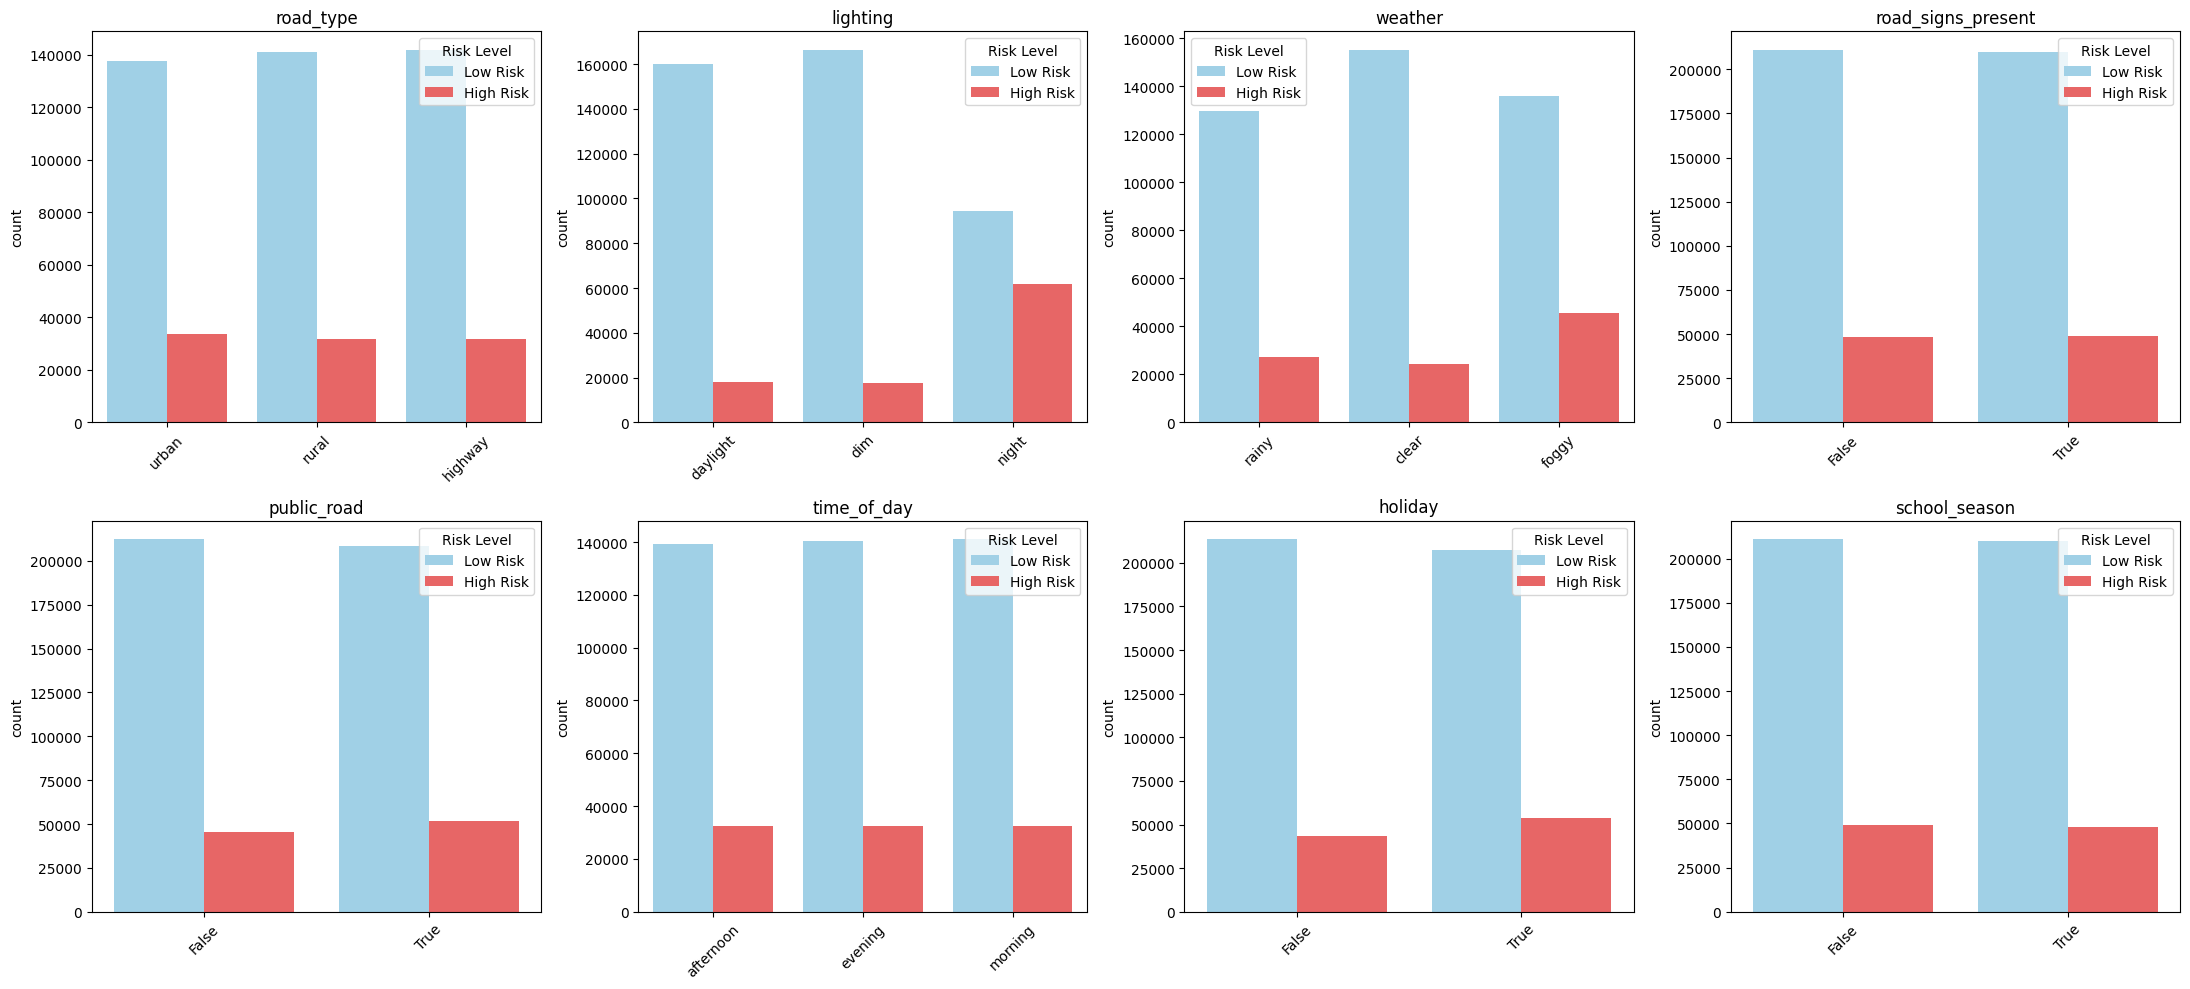

In [28]:
## Countplots of Low and High Risk for each categorical variable
cat_features = ['road_type', 'lighting', 'weather', 'road_signs_present', 'public_road', 'time_of_day', 'holiday', 'school_season']  

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, cat in enumerate(cat_features):
    sns.countplot(data=train, x=cat, hue='risk_label', ax=axes[i], palette=palette)
    axes[i].set_title(cat)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title="Risk Level")
    
plt.tight_layout()
plt.show()

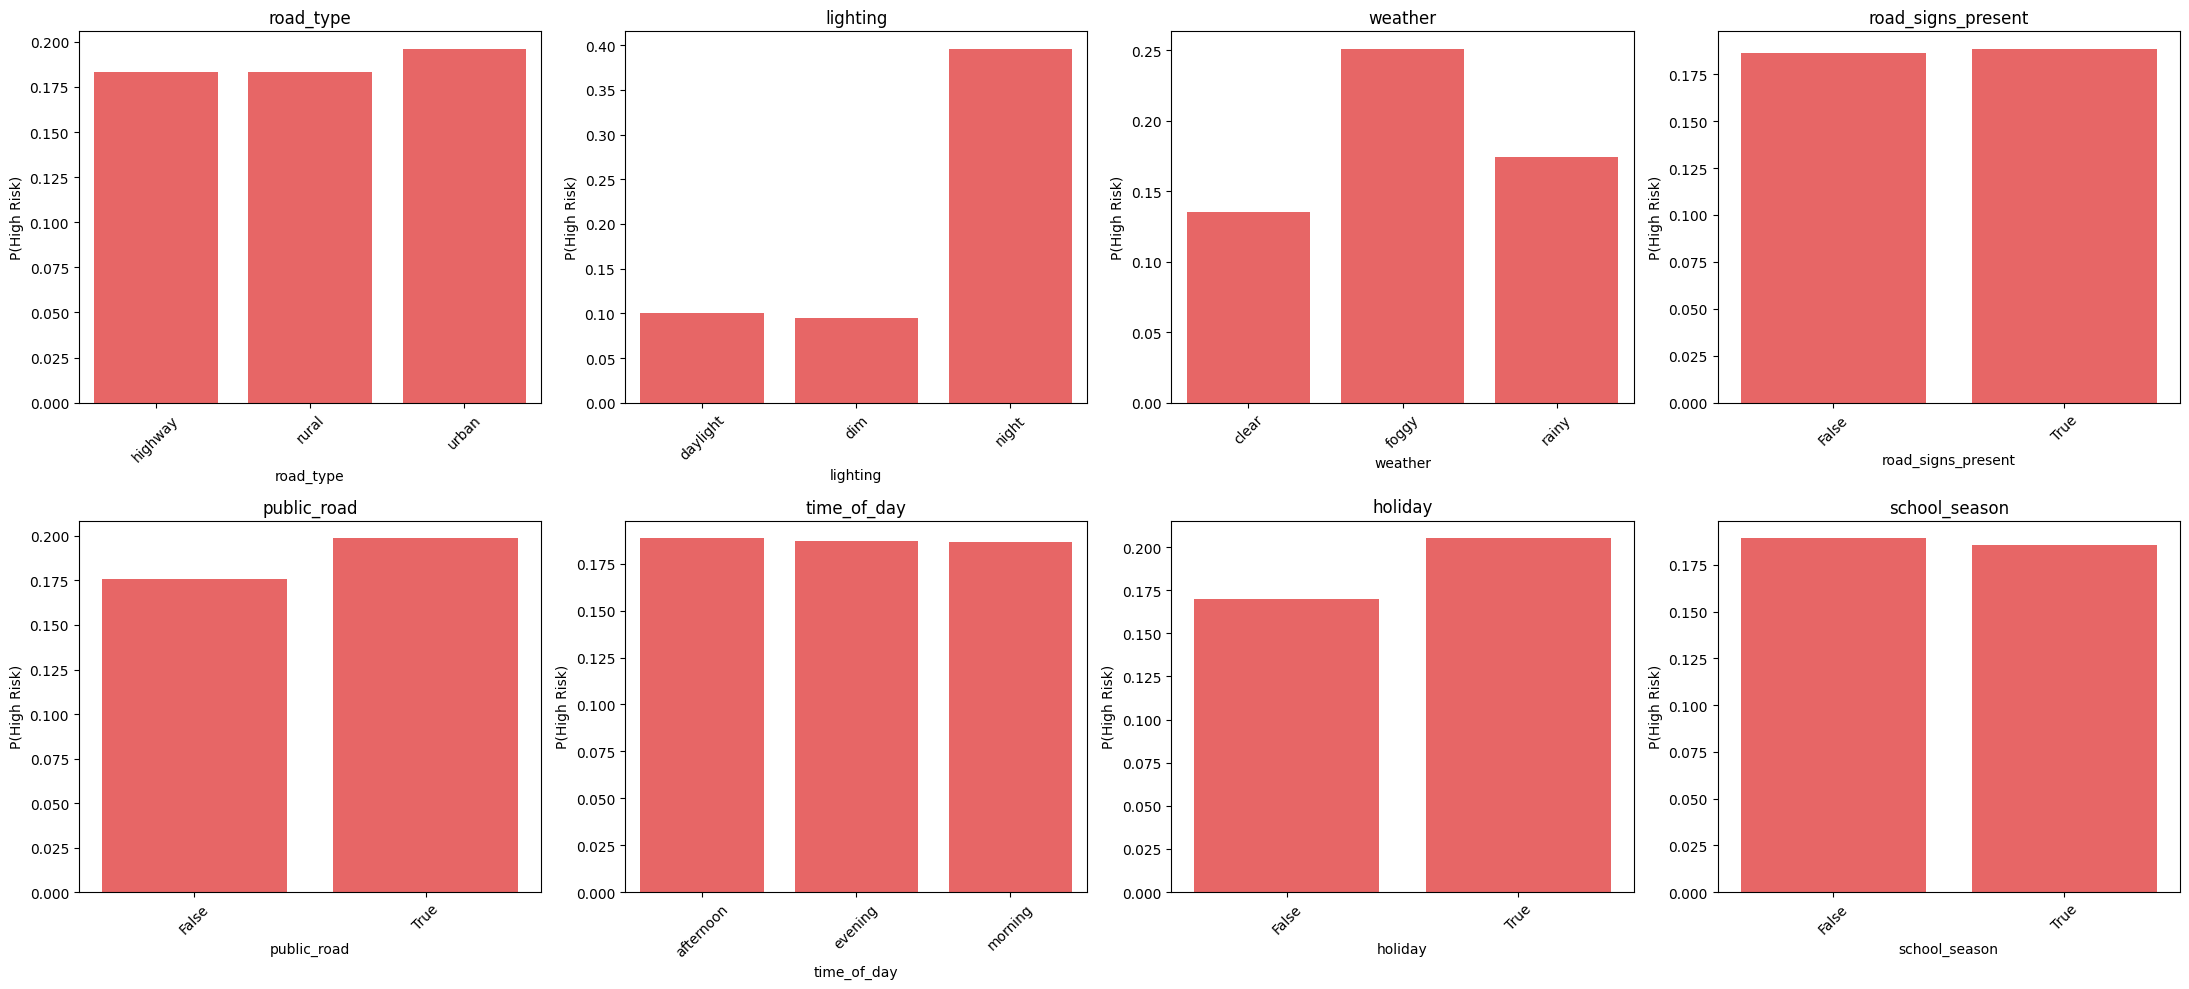

In [29]:
## Probability of High Risk for each categorical variable

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, cat in enumerate(cat_features):

    prob_df = (
        train.groupby(cat, observed=True)['risk_level']
        .mean()
        .reset_index(name='prob_high_risk')
    )

    sns.barplot(
        data=prob_df,
        x=cat,
        y='prob_high_risk',
        ax=axes[i],
        color='#FC5151'
    )

    axes[i].set_title(cat)
    axes[i].set_ylabel('P(High Risk)')
    axes[i].set_xlabel(cat)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [30]:
## Probability of High Risk for each categorical variable in tables

cat_tables = {}

overall_prob = train['risk_level'].mean()

for cat in cat_features:
    cat_prob = train.groupby(cat)['risk_level'].agg(
        count='count',
        probability='mean'
    )
    
    cat_prob['prob_difference'] = cat_prob['probability'] - overall_prob
    
    cat_tables[cat] = cat_prob

In [31]:
for cat in cat_features:
    styled = cat_tables[cat].style.format({
        'count': '{:,.0f}',
        'probability': '{:.3f}',
        'prob_difference': '{:+.3f}'
    }).set_caption(f"Risk Summary: {cat}")

    display(styled)

,count,probability,prob_difference
road_type,,,
highway,"173,672",0.183,-0.004
rural,"172,719",0.183,-0.004
urban,"171,363",0.196,+0.009


,count,probability,prob_difference
lighting,,,
daylight,"178,015",0.100,-0.087
dim,"183,826",0.095,-0.092
night,"155,913",0.396,+0.208


,count,probability,prob_difference
weather,,,
clear,"179,306",0.135,-0.052
foggy,"181,463",0.251,+0.063
rainy,"156,985",0.174,-0.013


,count,probability,prob_difference
road_signs_present,,,
False,"259,289",0.186,-0.001
True,"258,465",0.188,+0.001


,count,probability,prob_difference
public_road,,,
False,"257,709",0.176,-0.011
True,"260,045",0.199,+0.011


,count,probability,prob_difference
time_of_day,,,
afternoon,"171,507",0.188,+0.001
evening,"172,837",0.187,-0.000
morning,"173,410",0.187,-0.001


,count,probability,prob_difference
holiday,,,
False,"257,066",0.170,-0.018
True,"260,688",0.205,+0.018


,count,probability,prob_difference
school_season,,,
False,"260,164",0.189,+0.002
True,"257,590",0.186,-0.002


### Categorical Feature Findings
From the count plots and probability tables:
- road_type, road_signs_present, public_road, time_of_day, and school_season all showed very little variation in accident risk and were excluded from modeling.
- holiday showed some variation, but was ultimately insufficient to justify inclusion given its weak signal.
- lighting is a strong predictor, with night conditions showing substantially higher accident risk compared to daylight and dim conditions.
- weather is a moderate predictor, with foggy conditions associated with higher accident risk, compared to clear and rainy conditions. Rainy conditions showed a prob_difference of only -0.013, which is surprisingly similar to clear conditions.

## EDA Conclusion
Based on the correlation heatmap, distribution plots, and probability tables, 
the most informative variables for predicting accident risk are curvature, 
speed_limit, num_reported_accidents, weather, and lighting. Features such as 
num_lanes, road_type, road_signs_present, public_road, time_of_day, holiday, 
and school_season showed very little variation in accident risk and were 
excluded from modelling.

# Feature Engineering

## Preprocessing Measures Taken For Both Train and Test Datasets
1. Reloaded raw dataset and reapplied binarization of accident_risk
2. Binarization of speed_limit and num_reported accidents
    - is_highway created since EDA showed a sharp risk increase at 60mph and above
       - <60 = 0 (Not Highway), >=60 = 1 (Highway)
    - is_accident_prone created since EDA showed a sharp risk increase at 3 or more accidents
       - <3 = 0 (Not Accident Prone), >=3 = 1 (Accident Prone)
3. One-Hot Encoding for the two categorical features, weather and lighting
4. Created 4 interaction terms by multiplying two features together capturing the combined risk of dangerous conditions that logistic regression cannot detect on its own from raw features alone
   - speed_x_curvature: combines speed_limit and curvature
   - night_x_curvature: combines lighting_night and curvature
   - highway_x_night: combines is_highway and lighting_night
   - fog_x_highway: combines weather_foggy and is_highway
5. Applied StandardScaler to numeric features for Logistic Regression only since Decision Tree and Random Forest do not require scaling

In [32]:
# Reload raw data
train = pd.read_csv('/Users/tanvirsingh/Downloads/playground-series-s5e10/train.csv')
test = pd.read_csv('/Users/tanvirsingh/Downloads/playground-series-s5e10/test.csv')

# Convert continuous accident_risk to binary classification target
train['risk_level'] = (train['accident_risk'] >= 0.5).astype(int)
train['risk_label'] = train['risk_level'].map({0: 'Low Risk', 1: 'High Risk'})

In [33]:
# Feature Engineering Applied to both Train and Test
for df in [train, test]:
    ## Binarization of speed_limit and num_reported_accidents
    df['is_highway'] = (df['speed_limit'] >= 60).astype(int)
    df['is_accident_prone'] = (df['num_reported_accidents'] >= 3).astype(int)

    ## One-Hot Encoding of categorical features
    df['lighting'] = df['lighting'].str.lower()
    df['weather'] = df['weather'].str.lower()
train = pd.get_dummies(train, columns=['lighting', 'weather'], drop_first=True)
test = pd.get_dummies(test, columns=['lighting', 'weather'], drop_first=True)

for df in [train, test]:
    ## Interaction terms
    df['speed_x_curvature'] = df['speed_limit'] * df['curvature']
    df['night_x_curvature'] = df['lighting_night'] * df['curvature']
    df['highway_x_night'] = df['is_highway'] * df['lighting_night']
    df['fog_x_highway'] = df['weather_foggy'] * df['is_highway']

## Train/Validation Split
This is a Kaggle competition, so the test dataset does 
not contain target labels and it is used solely for generating prediction for submission. Therefore the training data is split into:
- Train (80%) — used to fit the models
- Validation (20%) — used to evaluate model performance in place of a labelled test set

This 80/20 split is commonly used in machine learning.


## Feature Selection:
Apart from the columns mentioned in the EDA Conclusion, these features were excluded from feature_cols: 
- id: row identifier with no predictive value
- accident_risk, risk_label: target related columns not used as features
- lighting, weather: replaced by one-hot encoded columns
  - lighting_dim 
  - lighting_night
  - weather_foggy
  - weather_rainy
- num_reported_accidents: replaced by is_accident_prone binary flag


In [34]:
# Variables from feature selection
feature_cols = [
    'curvature', 'speed_limit',
    'is_highway', 'is_accident_prone',
    'lighting_dim', 'lighting_night',
    'weather_foggy', 'weather_rainy',
    'speed_x_curvature', 'night_x_curvature',
    'highway_x_night', 'fog_x_highway'
]

# Define features and target
X = train[feature_cols]
y = train['risk_level']

# Split into 80% train and 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # class proportions are preserved
)

# Test used for generating predictions
X_test = test[feature_cols]

In [35]:
# Feature scaling for log reg
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

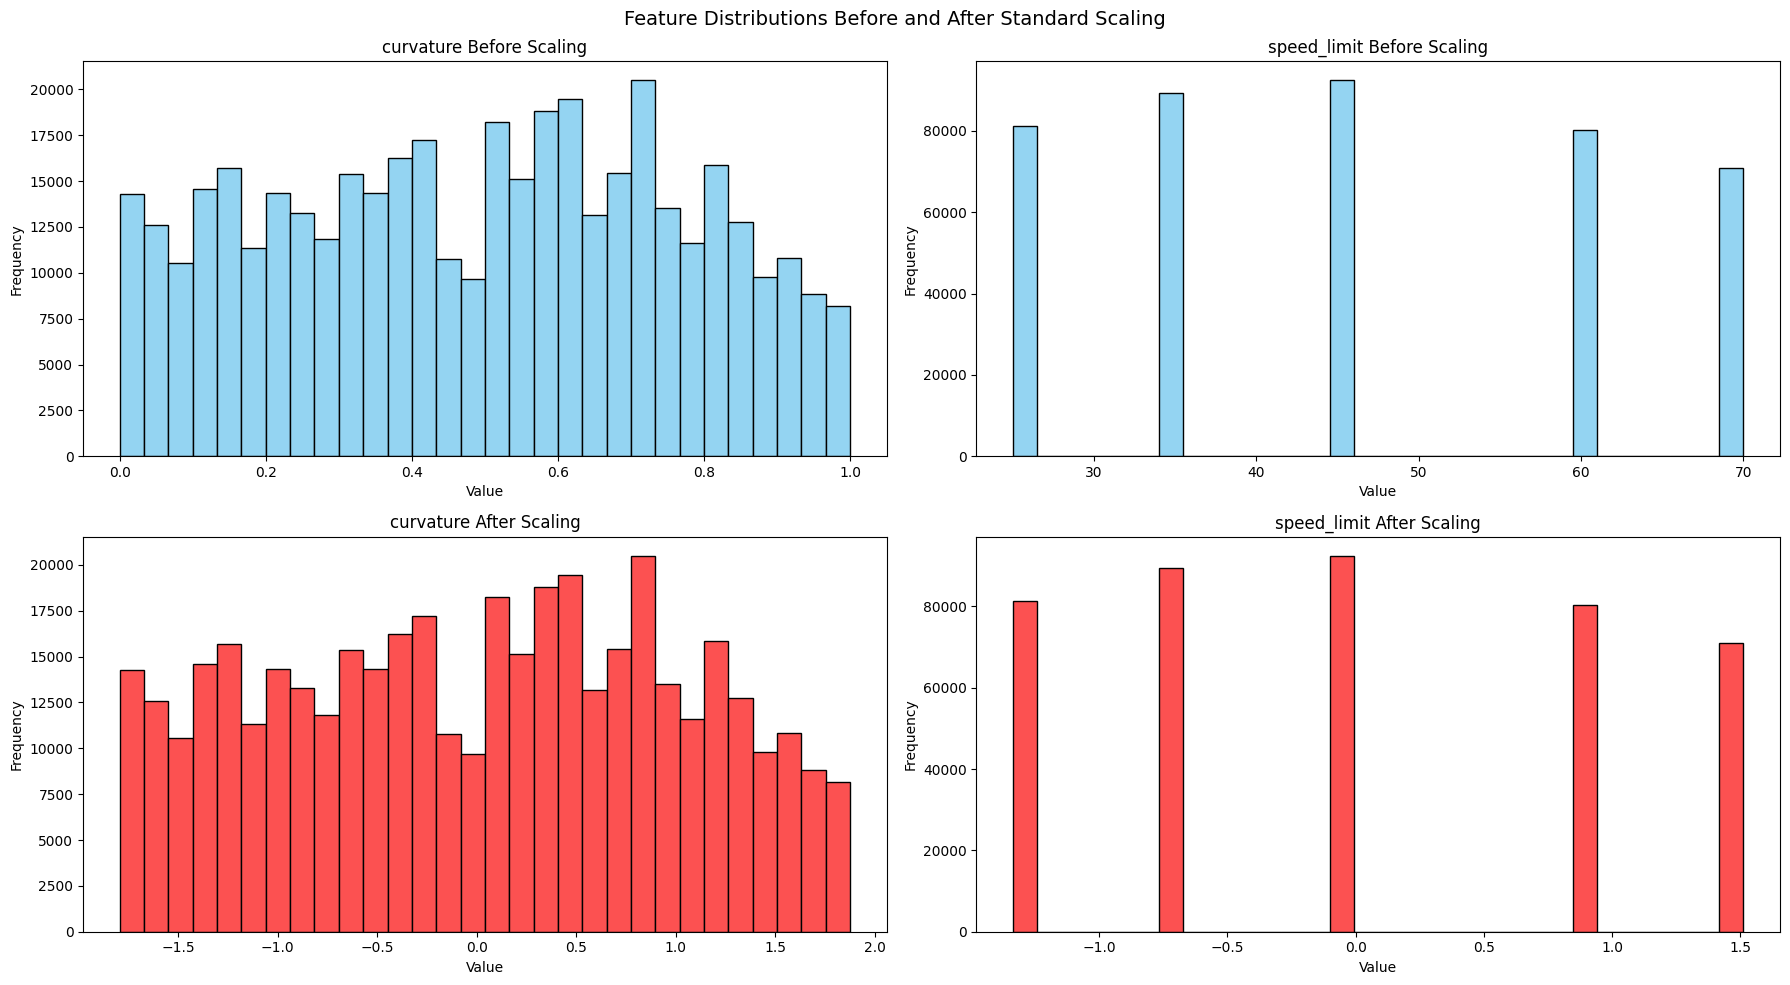

In [36]:
# Visualize the effect of scaling on curvature and speed_limit
scale_cols = ['curvature', 'speed_limit']
feature_cols_list = list(feature_cols)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for i, col in enumerate(scale_cols):
    col_idx = feature_cols_list.index(col)
    
    # Before scaling
    axes[0, i].hist(X_train.iloc[:, col_idx], bins=30, color='#94D4F2', edgecolor='black')
    axes[0, i].set_title(f'{col} Before Scaling')
    axes[0, i].set_xlabel('Value')
    axes[0, i].set_ylabel('Frequency')

    # After scaling 
    axes[1, i].hist(X_train_scaled[:, col_idx], bins=30, color='#FC5151', edgecolor='black')
    axes[1, i].set_title(f'{col} After Scaling')
    axes[1, i].set_xlabel('Value')
    axes[1, i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions Before and After Standard Scaling', fontsize=14)
plt.tight_layout()
plt.show()

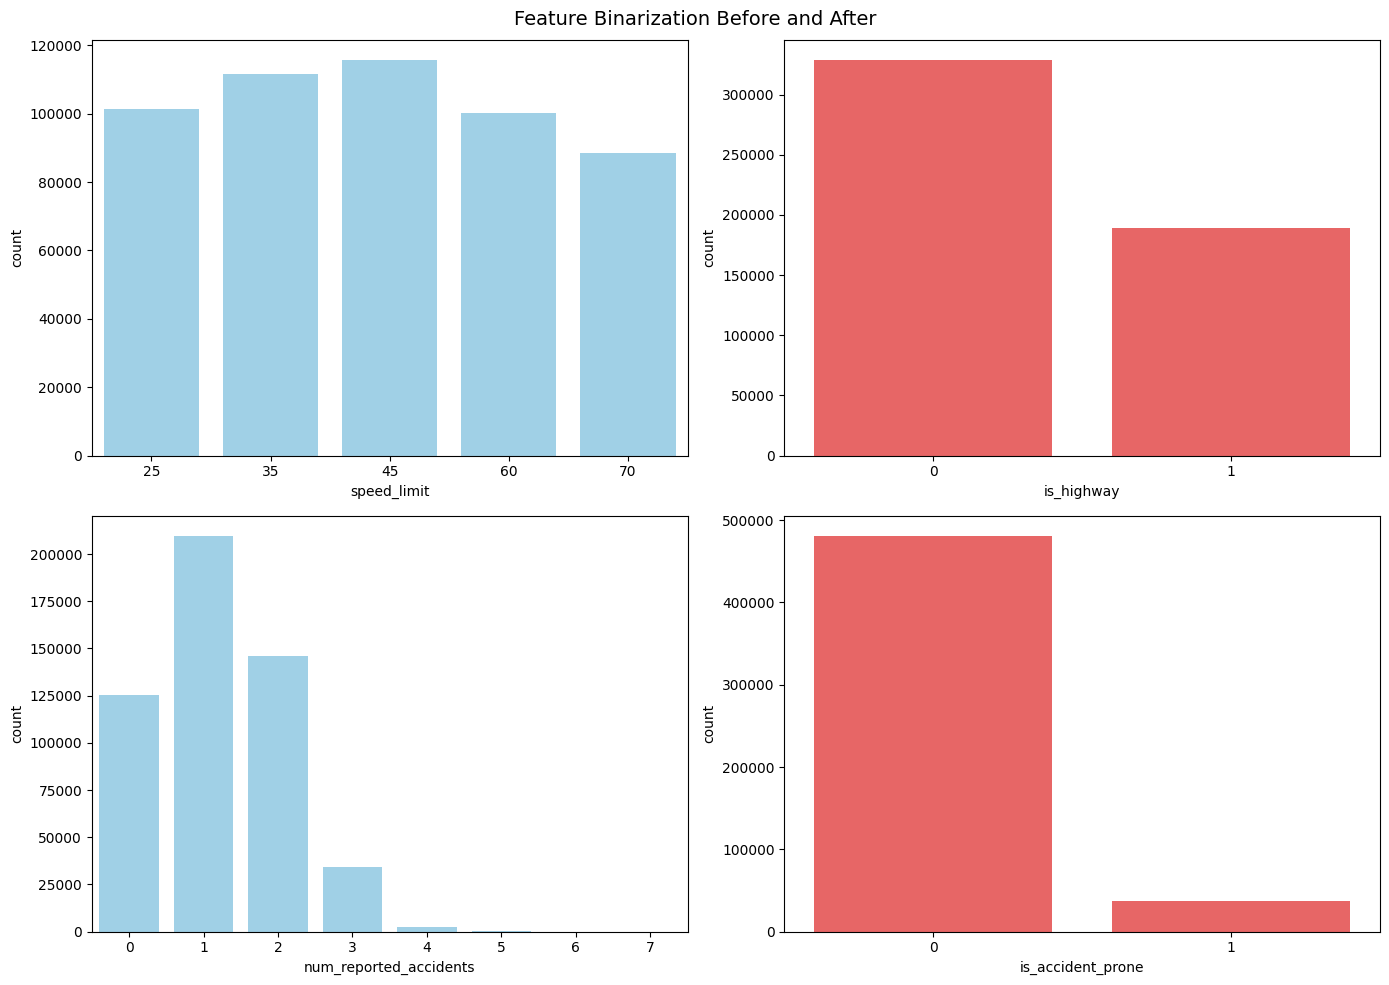

In [37]:
# Visualize the effect of binarization on speed_limit and num_reported_accidents

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# speed_limit before
sns.countplot(data=train, x='speed_limit', color='#94D4F2', ax=axes[0, 0])

# is_highway after
sns.countplot(data=train, x='is_highway', color='#FC5151', ax=axes[0, 1])

# num_reported_accidents before
sns.countplot(data=train, x='num_reported_accidents', color='#94D4F2', ax=axes[1, 0])

# is_accident_prone after
sns.countplot(data=train, x='is_accident_prone', color='#FC5151', ax=axes[1, 1])

plt.suptitle('Feature Binarization Before and After', fontsize=14)
plt.tight_layout()
plt.show()

# Machine Learning
- Logistic Regression
- Decision Tree
- Random Forest

## Logistic Regression (Accuracy 0.91; Best Model Overall)

In [38]:
lr = LogisticRegression(
    class_weight='balanced', # class weighing applied to address class imbalance
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [39]:
y_pred = lr.predict(X_val_scaled)
y_prob = lr.predict_proba(X_val_scaled)[:, 1]

In [40]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.91      0.94     84142
           1       0.69      0.93      0.80     19409

    accuracy                           0.91    103551
   macro avg       0.84      0.92      0.87    103551
weighted avg       0.93      0.91      0.92    103551



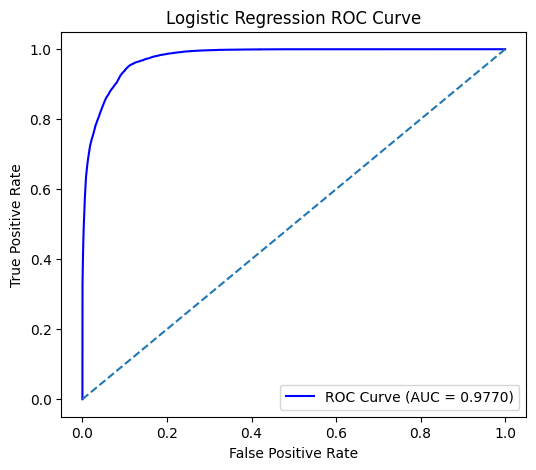

In [41]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')  

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend(loc='lower right')

plt.show()

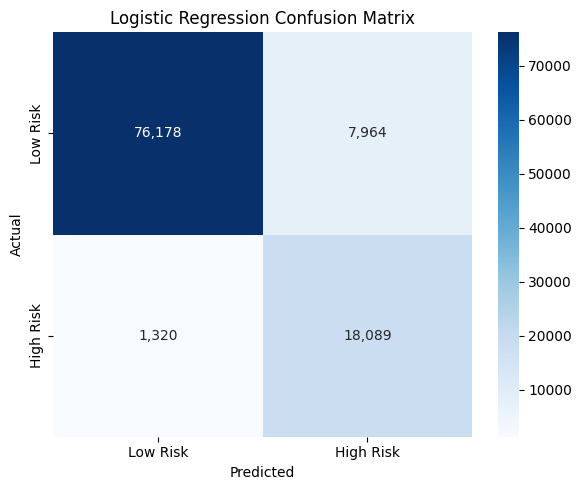

In [42]:
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=',',
    cmap='Blues',
    xticklabels=['Low Risk', 'High Risk'],
    yticklabels=['Low Risk', 'High Risk'],
    ax=ax
)
ax.set_title('Logistic Regression Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### Logistic Regression Findings:
- AUC-ROC is 0.9770, meaning that Logistic Regression is very good at distinguishing between low and high risk roads.
  
- Class 0 (Low Risk): Precision is 0.98 and recall is 0.91, meaning the model is very accurate when predicting low risk roads and catches most actual low risk cases.
  
- Class 1 (High Risk): Recall is 0.93, meaning that the model catches 93% of actually high risk roads, which is the most important metric for a road safety problem. Precision of 0.69 means 31% of roads predicted as high risk are actually low risk, which shows some false alarms but acceptable given the high recall. It is better for the model to read more false positives rather than having many high risk roads read as low risk.


## Decision Tree (Accuracy 0.90)

In [43]:
dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [44]:
y_pred_dt = dt.predict(X_val)
y_prob_dt = dt.predict_proba(X_val)[:, 1]

In [45]:
print(classification_report(y_val, y_pred_dt))

              precision    recall  f1-score   support

           0       0.99      0.89      0.94     84142
           1       0.67      0.95      0.79     19409

    accuracy                           0.90    103551
   macro avg       0.83      0.92      0.86    103551
weighted avg       0.93      0.90      0.91    103551



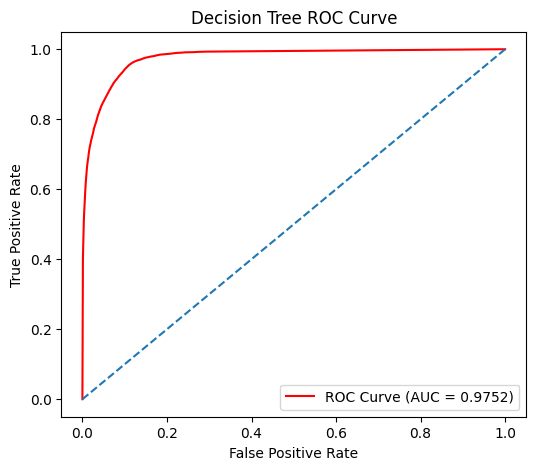

In [46]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob_dt)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='red', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')  

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.legend(loc='lower right')

plt.show()

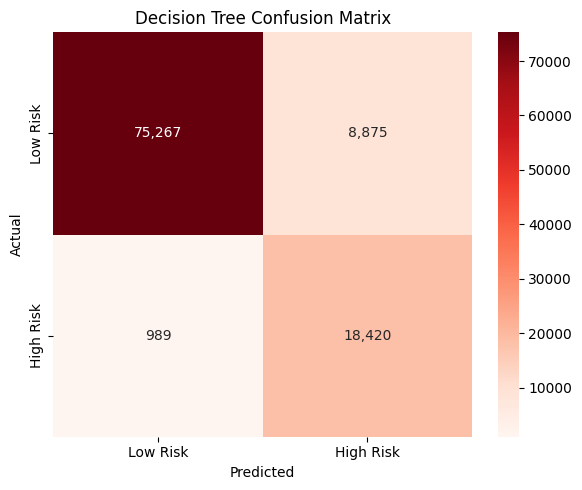

In [47]:
cm_dt = confusion_matrix(y_val, y_pred_dt)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt=',',
    cmap='Reds',
    xticklabels=['Low Risk', 'High Risk'],
    yticklabels=['Low Risk', 'High Risk'],
    ax=ax
)
ax.set_title('Decision Tree Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### Decision Tree Findings:
- AUC-ROC is 0.9752, which is lower than Logistic Regression, meaning that the Decision Tree model is less precise at distinguishing between low and high risk roads compared to Logistic Regression.
  
- Class 0 (Low Risk): Precision is 0.99 and recall is 0.89, meaning that when the model predicts a road is low risk, it is almost always correct, and it correctly identifies most actual low risk roads. Compared to Logistic Regression, this model achieves higher precision but slightly lower recall for this class.

- Class 1 (High Risk): Precision is 0.67 and recall is 0.95, meaning that this model is similar to Logistic Regression, where it predicts more high risk roads compared to low risk, but only 67% of those roads are actually high risk, which is less than the 69% from Logistic Regression. The recall is higher however, with 95% compared to the 93% in Logistic Regression.

## Random Forest (Accuracy 0.91)

In [48]:
rf = RandomForestClassifier(
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', n_jobs=-1,
                       random_state=42)

In [49]:
y_pred_rf = rf.predict(X_val)
y_prob_rf = rf.predict_proba(X_val)[:, 1]

In [50]:
print(classification_report(y_val, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.90      0.94     84142
           1       0.68      0.95      0.79     19409

    accuracy                           0.91    103551
   macro avg       0.83      0.92      0.86    103551
weighted avg       0.93      0.91      0.91    103551



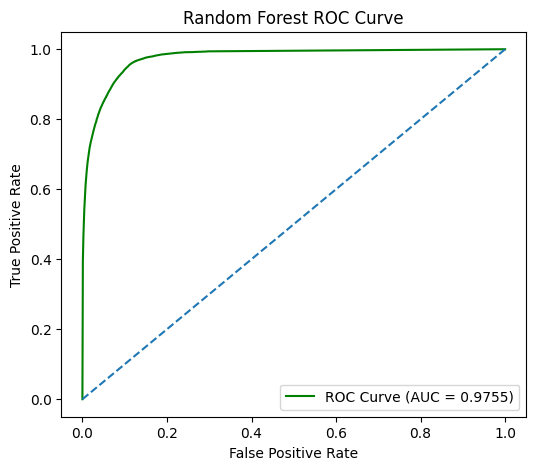

In [51]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob_rf)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='green', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')  

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc='lower right')

plt.show()

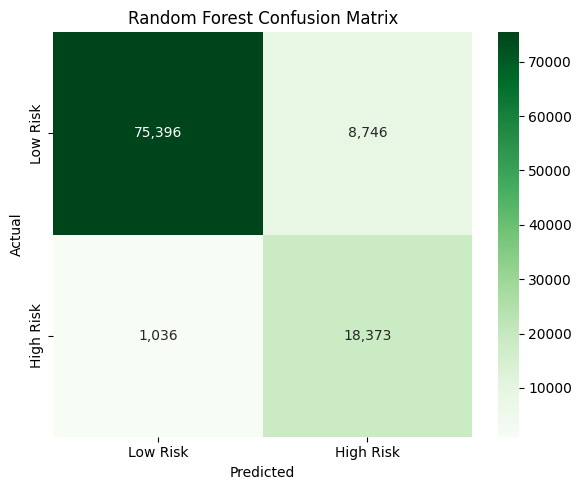

In [52]:
cm_rf = confusion_matrix(y_val, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt=',',
    cmap='Greens',
    xticklabels=['Low Risk', 'High Risk'],
    yticklabels=['Low Risk', 'High Risk'],
    ax=ax
)
ax.set_title('Random Forest Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### Random Forest Findings:
- AUC-ROC is 0.9755, which is higher than the Decision Tree model, but lower than Logistic Regression model.
  
- Class 0 (Low Risk): Precision is 0.99 and recall is 0.90, which is very close to the Decision Tree model.

- Class 1 (High Risk): Precision is 0.68 and recall is 0.95, which is very close to the Decision Tree model

- A model like Random Forest, which uses multiple decision trees to identify more complex, nonlinear patterns within the dataset, produced very similar results to the Decision Tree model. This suggests that using a more complex model does not significantly improve predictive performance for this dataset

# Conclusion
- Logistic Regression, Decision Tree, and Random Forest all had very similar results and all had an accuracy of 0.91, but in terms of the differing AUC values across all three models, the Logistic Regression model showed the best overall performance as it had the highest AUC of 0.9770.
  
- Even though the Decision Tree model had the least amount of false negatives according to the confusion matrices, it also yielded the most false positives by a substantial amount, highlighting a trade off toward increased sensitivity at the expense of precision. This can indicate overfitting in the model and produce less stable decision boundaries compared to Logistic Regression and Random Forest. 

# Apply ML to Challenge Test Set

In [53]:
X = train[feature_cols]
y = train['risk_level']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr_final = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_final.fit(X_scaled, y)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [54]:
X_test = test[feature_cols]
X_test_scaled = scaler.transform(X_test)

In [55]:
# Binary predictions
test_preds = lr_final.predict(X_test_scaled)

test['predicted_risk'] = test_preds

test['predicted_risk_label'] = test['predicted_risk'].map({
    0: 'Low Risk',
    1: 'High Risk'
})

In [56]:
submission = pd.DataFrame({
    'id': test['id'],
    'accident_risk': test['predicted_risk_label']  # shows Low Risk/High Risk
})

display(HTML(tabulate.tabulate(
    submission.head(10).values,
    tablefmt='html',
    headers=submission.columns.tolist()
)))

print(f'Total predictions: {submission.shape[0]}')
print(test['predicted_risk_label'].value_counts())


id,accident_risk
517754,Low Risk
517755,Low Risk
517756,Low Risk
517757,Low Risk
517758,Low Risk
517759,Low Risk
517760,Low Risk
517761,Low Risk
517762,Low Risk
517763,Low Risk


Total predictions: 172585
predicted_risk_label
Low Risk     129368
High Risk     43217
Name: count, dtype: int64
